# Uploading the Zip file

In [ ]:
from google.colab import files
uploaded = files.upload()   # upload the ZIP


Saving Project1-20251111T030347Z-1-001.zip to Project1-20251111T030347Z-1-001.zip


In [ ]:
import os
os.listdir()


['.config', 'Project1-20251111T030347Z-1-001.zip', 'sample_data']

In [ ]:
!unzip Project1-20251111T030347Z-1-001.zip -d /content/Project1


Archive:  Project1-20251111T030347Z-1-001.zip
  inflating: /content/Project1/Project1/requirements.txt  
  inflating: /content/Project1/Project1/utils.py  
  inflating: /content/Project1/Project1/inference.py  
  inflating: /content/Project1/Project1/model.py  
  inflating: /content/Project1/Project1/README.md  
  inflating: /content/Project1/Project1/dataset.py  
  inflating: /content/Project1/Project1/ADDA/val.csv  
  inflating: /content/Project1/Project1/main.py  
  inflating: /content/Project1/Project1/ADDA/train.csv  
  inflating: /content/Project1/Project1/ADDA/png_256/labels/CHUP-013_204.png  
  inflating: /content/Project1/Project1/ADDA/png_256/labels/MDA-081_59.png  
  inflating: /content/Project1/Project1/ADDA/png_256/labels/MDA-115_50.png  
  inflating: /content/Project1/Project1/ADDA/png_256/labels/MDA-059_246.png  
  inflating: /content/Project1/Project1/ADDA/png_256/labels/MDA-046_61.png  
  inflating: /content/Project1/Project1/ADDA/png_256/labels/MDA-187_60.png  
  infl

In [ ]:
%cd /content/Project1/Project1
!ls


/content/Project1/Project1
ADDA	    inference.py  model.py   requirements.docx	utils.py
dataset.py  main.py	  README.md  requirements.txt


In [ ]:
!pip install segmentation-models-pytorch albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
%%writefile /content/Project1/Project1/model.py
# ============================================================
# model.py — U-Net (ResNet34 + scSE Attention)
# ============================================================
import torch
import segmentation_models_pytorch as smp

class StudentModel(torch.nn.Module):
    def __init__(self, encoder_name="resnet34", pretrained=True):
        super().__init__()
        self.net = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights="imagenet" if pretrained else None,
            in_channels=3,
            classes=1,
            decoder_attention_type="scse"  # CBAM-like channel+spatial squeeze excitation
        )

    def forward(self, x):
        return self.net(x)


Overwriting /content/Project1/Project1/model.py


In [ ]:
%%writefile /content/Project1/Project1/dataset.py
# ============================================================
# dataset.py — CT / ADDA Segmentation Dataset with Albumentations
# ============================================================
import pandas as pd, numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset
from pathlib import Path


class SegDataset(Dataset):
    def __init__(self, csv_path, root_dir, augment=True, img_size=384):
        self.data = pd.read_csv(csv_path)
        self.root_dir = Path(root_dir)
        self.augment = augment
        self.img_size = img_size

        if augment:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.Rotate(limit=10, p=0.5),
                A.RandomBrightnessContrast(p=0.2),
                A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
                ToTensorV2()
            ])

    def fix_path(self, p):
        """Fixes relative or absolute paths to work across OS/colab."""
        p = str(p).strip().replace("\\", "/")
        # If already absolute or contains root, leave it
        if str(self.root_dir) in p:
            return p
        # Otherwise, prepend root_dir
        return str((self.root_dir / p).resolve())

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = self.fix_path(row["ct_path"])
        mask_path = self.fix_path(row["label_path"])

        # Load as grayscale (CT single channel)
        img = np.array(Image.open(img_path).convert("L"), dtype=np.float32)
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
        mask = (mask > 0.5).astype(np.float32)

        # Convert grayscale to 3-channel
        img = np.stack([img, img, img], axis=-1)

        transformed = self.transform(image=img, mask=mask)
        img_t, mask_t = transformed["image"], transformed["mask"].unsqueeze(0)
        return img_t, mask_t



Overwriting /content/Project1/Project1/dataset.py


In [ ]:
!apt-get update -y
!apt-get install -y build-essential python3-dev
!pip install git+https://github.com/lucasb-eyer/pydensecrf.git


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,153 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,835 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,876 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/p

In [ ]:
%%writefile /content/Project1/Project1/inference.py
import argparse, torch, numpy as np, cv2
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as TF
from model import StudentModel

try:
    import pydensecrf.densecrf as dcrf
    from pydensecrf.utils import unary_from_softmax
    HAS_CRF = True
except Exception:
    HAS_CRF = False


def preprocess(img_path, img_size):
    im = Image.open(img_path).convert("RGB")
    im = TF.resize(im, [img_size, img_size], antialias=True)
    return TF.to_tensor(im).unsqueeze(0), np.array(im)


def apply_crf(image, prob):
    if not HAS_CRF:
        return prob

    h, w = image.shape[:2]
    unary = unary_from_softmax(np.stack([1 - prob, prob], axis=0))

    d = dcrf.DenseCRF2D(w, h, 2)
    d.setUnaryEnergy(unary)

    d.addPairwiseGaussian(3, 3)
    d.addPairwiseBilateral(60, 13, image, 10)

    Q = np.array(d.inference(5))     # <-- FIXED
    return Q[1].reshape(h, w)


def postprocess(prob, thr=0.5):
    m = (prob >= thr).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(m, 8)

    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        m = (labels == largest).astype(np.uint8)

    kernel = np.ones((3, 3), np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel)
    return m * 255

def overlay(original, mask):
    # Ensure original is 3-channel
    if len(original.shape) == 2:  # grayscale → convert
        orig_color = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    else:  # already RGB
        orig_color = original

    color_mask = np.stack([mask*0, mask, mask*0], axis=-1).astype(np.uint8)
    return cv2.addWeighted(orig_color, 0.6, color_mask, 0.4, 0)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--ckpt", required=True)
    ap.add_argument("--image", default=None)
    ap.add_argument("--in_dir", default=None)
    ap.add_argument("--out_dir", default="./preds")
    ap.add_argument("--img_size", type=int, default=256)
    ap.add_argument("--thr", type=float, default=0.5)
    args = ap.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load checkpoint
    ck = torch.load(args.ckpt, map_location=device)

    # Your StudentModel likely expects no constructor args
    model = StudentModel().to(device)

    # When saving, you saved ONLY state_dict — so handle both formats
    if "state_dict" in ck:
        model.load_state_dict(ck["state_dict"])
    else:
        model.load_state_dict(ck)

    model.eval()

    out = Path(args.out_dir)
    out.mkdir(parents=True, exist_ok=True)

    paths = []
    if args.image:
        paths.append(Path(args.image))
    if args.in_dir:
        for ext in ("*.png", "*.jpg", "*.jpeg"):
            paths += list(Path(args.in_dir).glob(ext))

    assert paths, "❗ Provide --image or --in_dir"

    for p in paths:
        x, orig = preprocess(p, args.img_size)
        x = x.to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()

        if HAS_CRF:
            prob = apply_crf(orig, prob)

        mask = postprocess(prob, args.thr)

        Image.fromarray(mask).save(out / f"{p.stem}_mask.png")
        cv2.imwrite(str(out / f"{p.stem}_overlay.png"), overlay(orig, mask))

    print(f"Results saved to {out} ({'with CRF' if HAS_CRF else 'no CRF'})")


if __name__ == "__main__":
    main()


Overwriting /content/Project1/Project1/inference.py


In [ ]:
import sys
sys.path.append("/content/Project1/Project1")


In [ ]:
%%writefile /content/Project1/Project1/main.py
# ============================================================
# main.py — Balanced U-Net Trainer (Hybrid Loss, scSE Attention)
# with Early Stopping + LR Scheduler
# ============================================================
import os, random, numpy as np, torch, argparse
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from tqdm import tqdm
from dataset import SegDataset
from model import StudentModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("./runs", exist_ok=True)

# ============================================================
# 🔹 Early Stopping
# ============================================================
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = None
        self.counter = 0
        self.stop = False

    def __call__(self, metric):
        if self.best is None:
            self.best = metric
            return

        if self.mode == 'max':
            improved = metric > (self.best + self.min_delta)
        else:
            improved = metric < (self.best - self.min_delta)

        if improved:
            self.best = metric
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


# ============================================================
# 🔹 Loss Functions
# ============================================================
def weighted_bce_dice(pred, target, pos_weight=3.0):
    bce = F.binary_cross_entropy_with_logits(
        pred, target,
        pos_weight=torch.tensor(pos_weight, device=pred.device)
    )
    p = torch.sigmoid(pred)
    smooth = 1.
    inter = (p * target).sum()
    dice = 1 - ((2 * inter + smooth) / (p.sum() + target.sum() + smooth))
    return 0.6 * bce + 0.4 * dice


def focal_bce(pred, target, gamma=2.0):
    p = torch.sigmoid(pred)
    bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    pt = torch.where(target == 1, p, 1 - p)
    return (((1 - pt) ** gamma) * bce).mean()


def hybrid_loss(pred, target):
    return 0.4 * focal_bce(pred, target) + 0.6 * weighted_bce_dice(pred, target)


def dice_coef(pred, target):
    p = (torch.sigmoid(pred) > 0.5).float()
    smooth = 1.
    return (2 * (p * target).sum() + smooth) / (p.sum() + target.sum() + smooth)


# ============================================================
# 🔹 Training Function
# ============================================================
def train(train_csv, val_csv, root="./ADDA", epochs=50, batch_size=8, lr=1e-3):

    # Dataset
    tr_ds = SegDataset(train_csv, root, augment=True)
    va_ds = SegDataset(val_csv, root, augment=False)

    # ------------------------------------------------------------
    # Balanced Sampling
    # ------------------------------------------------------------
    df = pd.read_csv(train_csv)

    tumor_idx = []
    for i, r in df.iterrows():
        mask_path = os.path.join(root, str(r["label_path"]))
        try:
            mask = np.array(Image.open(mask_path).convert("L"))
            if mask.sum() > 0:
                tumor_idx.append(i)
        except:
            pass

    non_tumor_idx = [i for i in range(len(df)) if i not in tumor_idx]

    balanced_idx = tumor_idx * 2 + random.sample(
        non_tumor_idx,
        min(len(non_tumor_idx), len(tumor_idx) * 2)
    )

    sampler = SubsetRandomSampler(balanced_idx)

    tr_ld = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    va_ld = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    # ------------------------------------------------------------
    # Model + Optimizer
    # ------------------------------------------------------------
    model = StudentModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", patience=5, factor=0.5
    )

    early_stop = EarlyStopping(patience=10, mode='max')

    best, trL, vaD = 0., [], []

    print(f"\n🚀 Starting training for {epochs} epochs\n")

    # ============================================================
    # Epoch Loop
    # ============================================================
    for e in range(epochs):
        model.train()
        runL = 0.

        loop = tqdm(tr_ld, desc=f"Epoch {e+1}/{epochs} [Train]", leave=False)
        for x, y in loop:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            p = model(x)
            L = hybrid_loss(p, y)
            L.backward()
            opt.step()

            runL += L.item() * x.size(0)
            loop.set_postfix(loss=L.item())

        tr_loss = runL / len(tr_ld.dataset)

        # ----------------------------
        # Validation
        # ----------------------------
        model.eval()
        val_d = 0.

        vloop = tqdm(va_ld, desc=f"Epoch {e+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for x, y in vloop:
                x, y = x.to(device), y.to(device)
                p = model(x)
                d = dice_coef(p, y).item()
                val_d += d * x.size(0)
                vloop.set_postfix(dice=d)

        val_d /= len(va_ld.dataset)
        sched.step(val_d)

        print(f"Epoch {e+1:03d}/{epochs} | TrainLoss={tr_loss:.4f} | ValDice={val_d:.4f}")

        # Save best model
        if val_d > best:
            best = val_d
            torch.save(model.state_dict(), "./runs/best_unet_balanced.pth")
            print(f"✅ Saved best model (Dice={best:.4f})")

        trL.append(tr_loss)
        vaD.append(val_d)

        # ----------------------------
        # Early Stopping Check
        # ----------------------------
        early_stop(val_d)
        if early_stop.stop:
            print("⛔ Early stopping triggered!")
            break

    # ------------------------------------------------------------
    # Plot Curves
    # ------------------------------------------------------------
    plt.figure(figsize=(6,4))
    plt.plot(trL, label="Train Loss")
    plt.plot(vaD, label="Val Dice")
    plt.legend()
    plt.xlabel("Epoch")
    plt.title("Training Progress")
    plt.savefig("./runs/training_curve.png")
    plt.show()

    print(f"\n🎯 Final Best Dice={best:.4f}")
    print("📌 Model saved at: ./runs/best_unet_balanced.pth")
    print("📈 Curve saved at: ./runs/training_curve.png")


# ============================================================
# 🔹 CLI
# ============================================================
if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_dir", type=str, default="./ADDA")
    ap.add_argument("--train_csv", type=str, default="train.csv")
    ap.add_argument("--val_csv", type=str, default="val.csv")
    ap.add_argument("--epochs", type=int, default=50)
    ap.add_argument("--batch_size", type=int, default=8)
    ap.add_argument("--lr", type=float, default=1e-3)
    args = ap.parse_args()

    train(
        os.path.join(args.data_dir, args.train_csv),
        os.path.join(args.data_dir, args.val_csv),
        root=args.data_dir,
        epochs=args.epochs,
        batch_size=args.batch_size,
        lr=args.lr
    )


Overwriting /content/Project1/Project1/main.py


In [ ]:
!python -u /content/Project1/Project1/main.py \
  --data_dir /content/Project1/Project1/ADDA \
  --train_csv train.csv \
  --val_csv val.csv \
  --epochs 40 \
  --batch_size 4 \
  --lr 1e-4



🚀 Starting training for 40 epochs

Epoch 001/40 | TrainLoss=0.7084 | ValDice=0.3555
✅ Saved best model (Dice=0.3555)
Epoch 002/40 | TrainLoss=0.5392 | ValDice=0.3942
✅ Saved best model (Dice=0.3942)
Epoch 003/40 | TrainLoss=0.4640 | ValDice=0.4347
✅ Saved best model (Dice=0.4347)
Epoch 004/40 | TrainLoss=0.3959 | ValDice=0.4989
✅ Saved best model (Dice=0.4989)
Epoch 005/40 | TrainLoss=0.3426 | ValDice=0.4764
Epoch 006/40 | TrainLoss=0.3116 | ValDice=0.4927
Epoch 007/40 | TrainLoss=0.2969 | ValDice=0.5046
✅ Saved best model (Dice=0.5046)
Epoch 008/40 | TrainLoss=0.2798 | ValDice=0.4998
Epoch 009/40 | TrainLoss=0.2645 | ValDice=0.5270
✅ Saved best model (Dice=0.5270)
Epoch 010/40 | TrainLoss=0.2580 | ValDice=0.5204
Epoch 011/40 | TrainLoss=0.2450 | ValDice=0.5456
✅ Saved best model (Dice=0.5456)
Epoch 012/40 | TrainLoss=0.2402 | ValDice=0.5577
✅ Saved best model (Dice=0.5577)
Epoch 013/40 | TrainLoss=0.2398 | ValDice=0.5257
Epoch 014/40 | TrainLoss=0.2247 | ValDice=0.5533
Epoch 015/40 |

In [ ]:
!python /content/Project1/Project1/inference.py \
  --ckpt /content/Project1/Project1/runs/best_unet_balanced.pth \
  --in_dir /content/Project1/Project1/ADDA/png_256/images \
  --img_size 256 \
  --thr 0.5 \
  --out_dir /content/Project1/Project1/preds


Results saved to /content/Project1/Project1/preds (with CRF)


✅ Loaded model: /content/Project1/Project1/runs/best_unet_balanced.pth
📁 Validation samples: 100


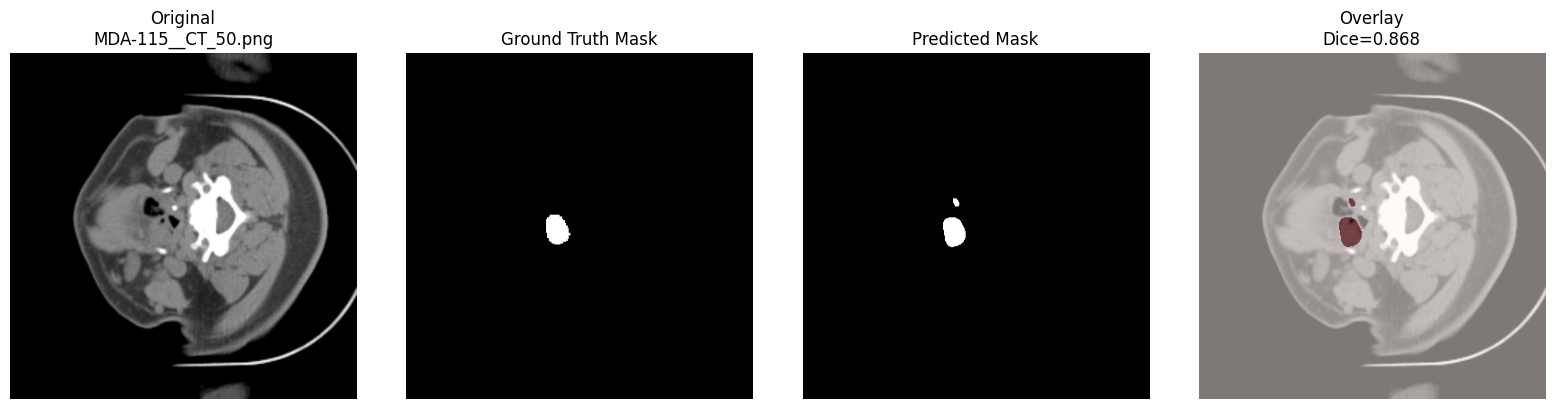

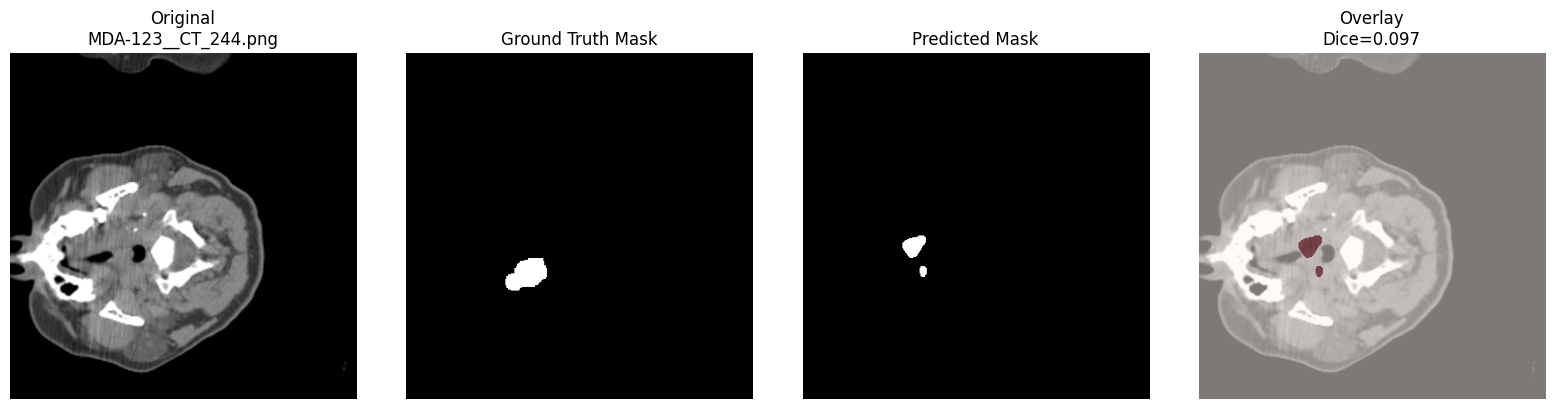

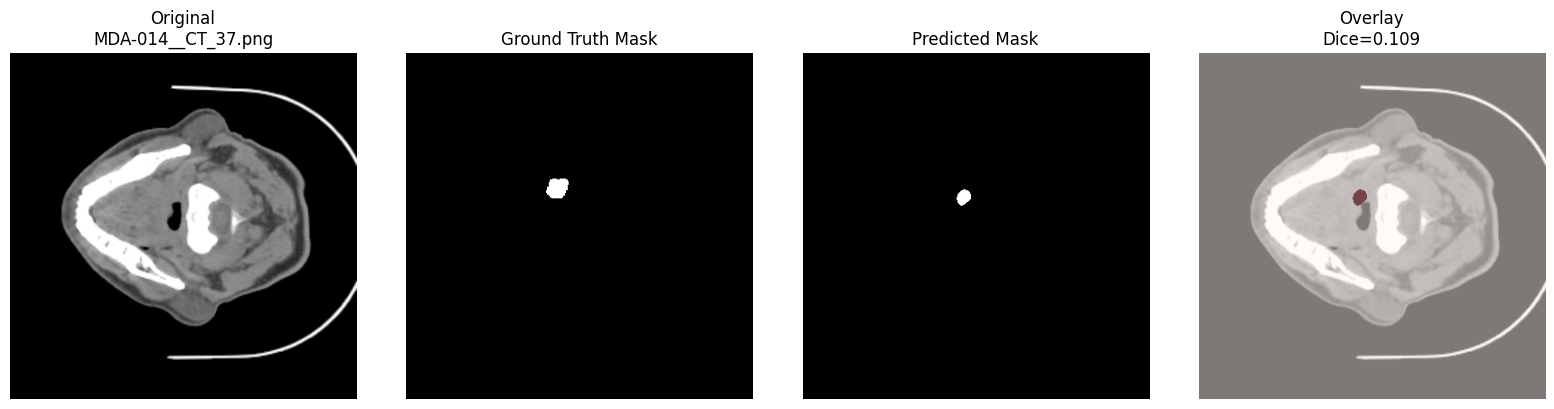

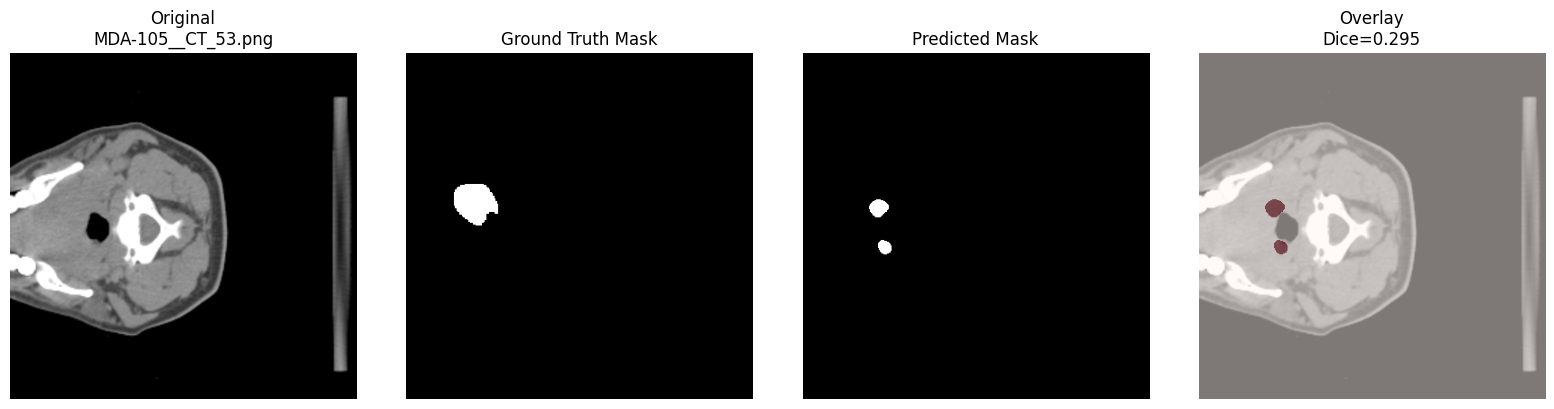

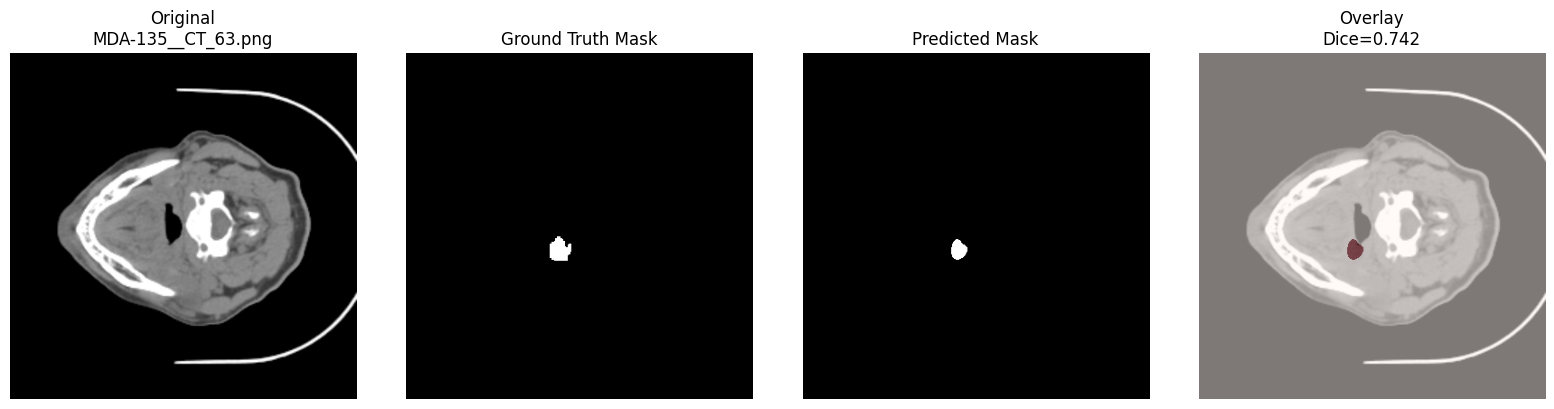

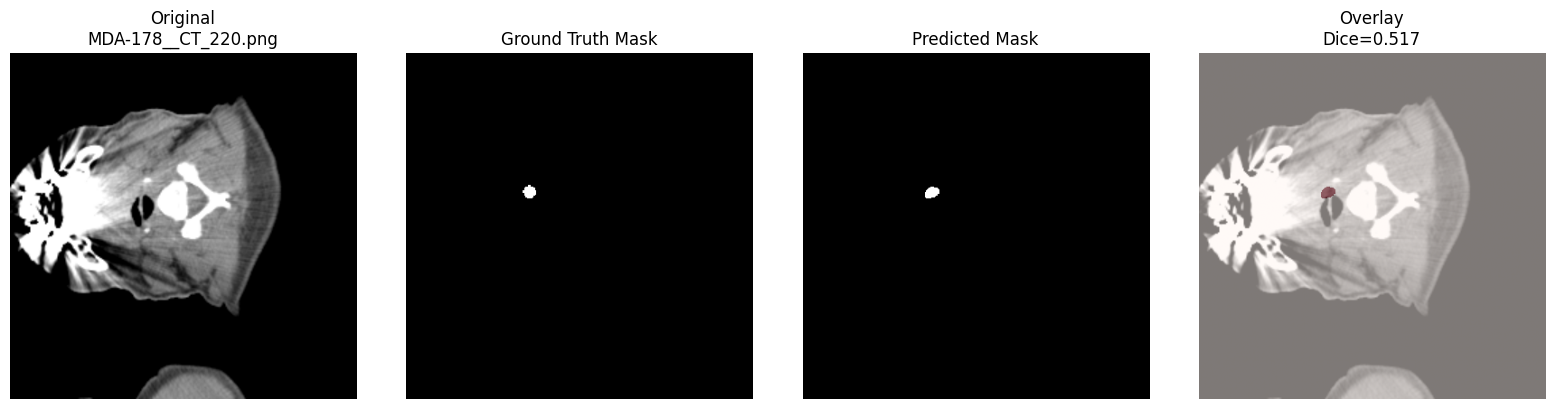

🎉 DONE — Visualizations saved to: /content/Project1/Project1/runs/visuals_final
📊 Dice summary saved to: /content/Project1/Project1/runs/visuals_final/dice_summary.csv


In [ ]:
# ============================================================
# 🩻 Post-Training Visualization (FINAL VERIFIED VERSION)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_opening
from pathlib import Path
import random, csv, os

from model import StudentModel
from dataset import SegDataset

# --------------------------
# 🔧 Load trained model
# --------------------------
model_path = "/content/Project1/Project1/runs/best_unet_balanced.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StudentModel().to(device)

ck = torch.load(model_path, map_location=device)
if isinstance(ck, dict) and "state_dict" in ck:
    model.load_state_dict(ck["state_dict"])
else:
    model.load_state_dict(ck)

model.eval()
print("✅ Loaded model:", model_path)

# --------------------------
# 📁 Load validation dataset
# --------------------------
BASE_DIR = "/content/Project1/Project1/ADDA"
VAL_CSV = f"{BASE_DIR}/val.csv"

val_ds = SegDataset(VAL_CSV, BASE_DIR, augment=False)
print("📁 Validation samples:", len(val_ds))

# Pick random samples
samples = list(range(6))

# Save directory
save_dir = Path("/content/Project1/Project1/runs/visuals_final")
save_dir.mkdir(parents=True, exist_ok=True)

csv_file = save_dir / "dice_summary.csv"
with open(csv_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Image", "Label", "Dice"])

# ============================================================
# 🎨 Visualization Loop
# ============================================================
for idx in samples:

    img, mask = val_ds[idx]  # returns (image, mask)

    # FIXED: Use correct dataset attributes
    img_path = val_ds.data.iloc[idx]["ct_path"]
    mask_path = val_ds.data.iloc[idx]["label_path"]

    # ---- Prediction ----
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device))).cpu().numpy()[0, 0]

    img_np = img.squeeze().numpy()
    mask_np = mask.squeeze().numpy()

    pred_bin = (pred > 0.5).astype(np.uint8)
    pred_bin = binary_opening(pred_bin, structure=np.ones((3, 3)))

    # ---- Dice ----
    inter = np.sum(pred_bin * mask_np)
    dice = (2 * inter + 1e-7) / (np.sum(pred_bin) + np.sum(mask_np) + 1e-7)

    # ---- Plot ----
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img_np[0], cmap="gray")     # since img is 3-channel normalized
    plt.title(f"Original\n{os.path.basename(img_path)}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(img_np[0], cmap="gray")
    plt.imshow(pred_bin, cmap="Reds", alpha=0.5)
    plt.title(f"Overlay\nDice={dice:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_dir / f"{Path(img_path).stem}_viz.png", bbox_inches="tight")
    plt.show()

    # Save CSV
    with open(csv_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([img_path, mask_path, f"{dice:.4f}"])

print("🎉 DONE — Visualizations saved to:", save_dir)
print("📊 Dice summary saved to:", csv_file)


In [ ]:
!zip -r project1.zip /content/Project1


  adding: content/Project1/ (stored 0%)
  adding: content/Project1/Project1/ (stored 0%)
  adding: content/Project1/Project1/dataset.py (deflated 63%)
  adding: content/Project1/Project1/preds/ (stored 0%)
  adding: content/Project1/Project1/preds/MDA-135__CT_58_mask.png (deflated 48%)
  adding: content/Project1/Project1/preds/MDA-190__CT_248_mask.png (deflated 48%)
  adding: content/Project1/Project1/preds/CHUP-068__CT_237_mask.png (deflated 48%)
  adding: content/Project1/Project1/preds/CHUP-043__CT_247_overlay.png (deflated 11%)
  adding: content/Project1/Project1/preds/MDA-017__CT_24_overlay.png (deflated 13%)
  adding: content/Project1/Project1/preds/MDA-041__CT_63_mask.png (deflated 48%)
  adding: content/Project1/Project1/preds/MDA-159__CT_67_mask.png (deflated 48%)
  adding: content/Project1/Project1/preds/MDA-164__CT_227_overlay.png (deflated 17%)
  adding: content/Project1/Project1/preds/MDA-173__CT_30_overlay.png (deflated 13%)
  adding: content/Project1/Project1/preds/MDA-0

In [ ]:
from google.colab import files
files.download("project1.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>